# Phase 0 — EDA & Preprocessing
**DiagGen+ | Advanced AI Group Project 2026**

## Objectives
1. Load and inspect the dataset.
2. Analyse class distribution — identify rare disease classes.
3. Run the NLP preprocessing pipeline and verify output quality.
4. Produce the 80/10/10 train/val/test split and save to `data/processed/`.

> **Gate 0 complete** when: clean dataset exists, class distribution chart saved, preprocessing verified.

In [15]:
import sys
sys.path.insert(0, '..')  # allow imports from project root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.utils.config_loader import cfg, get
from src.utils.logger import get_logger
from src.preprocessing.cleaner import preprocess, preprocess_batch
from src.training.trainer import load_dataset, split_data, build_label_maps

logger = get_logger('phase0_eda')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Imports OK')

Imports OK


## 1. Load Dataset

In [17]:
# Update path to match your downloaded file (see data/README.md)
DATA_PATH = Path('../data/raw/symptom_to_diagnosis.csv')

df = load_dataset(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

2026-06-13 22:10:38 | INFO     | src.training.trainer | Loaded dataset: 1065 rows, 22 disease classes.
Shape: (1065, 2)


,disease,symptoms
0,cervical spondylosis,I've been having a lot of pain in my neck and ...
1,impetigo,I have a rash on my face that is getting worse...
2,urinary tract infection,I have been urinating blood. I sometimes feel ...
3,arthritis,I have been having trouble with my muscles and...
4,dengue,I have been feeling really sick. My body hurts...


## 2. Class Distribution — Identify Rare Classes

In [21]:
counts = df['disease'].value_counts()
rare_threshold = get('data.rare_class_threshold', 100)

print(f'Total classes:  {len(counts)}')
print(f'Rare classes:   {(counts < rare_threshold).sum()}  (< {rare_threshold} samples)')

Total classes:  22
Rare classes:   22  (< 100 samples)


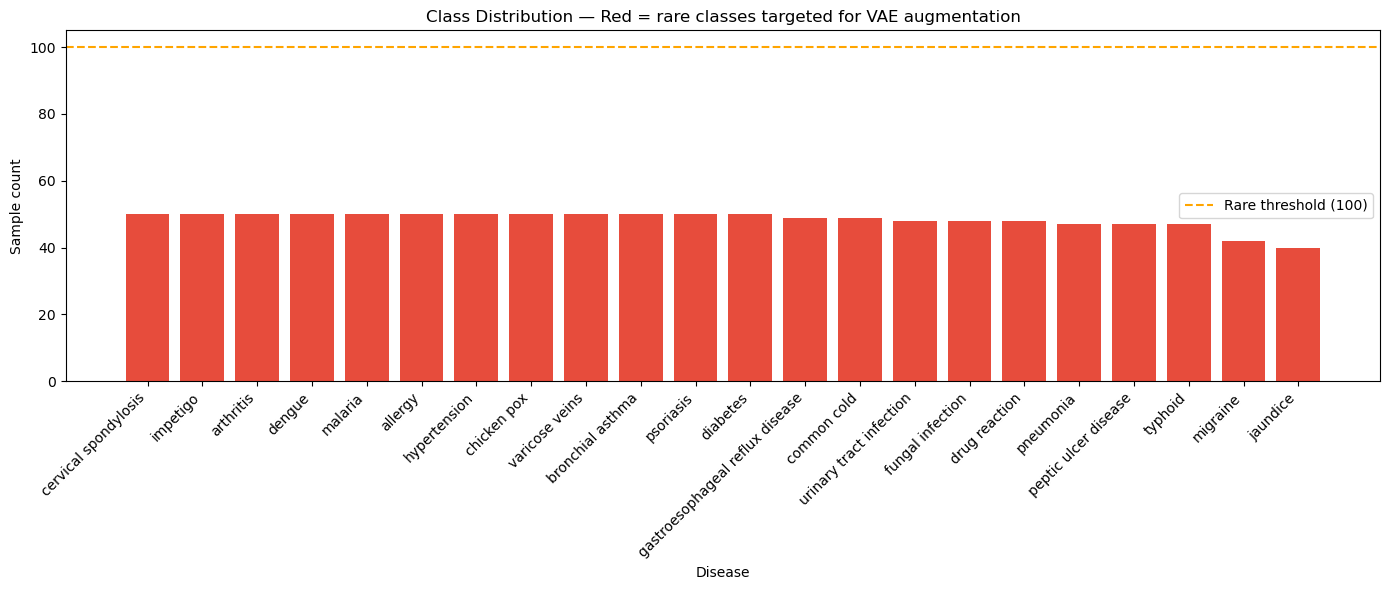

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
colours = ['#E74C3C' if c < rare_threshold else '#2E75B6' for c in counts.values]
ax.bar(counts.index, counts.values, color=colours)
ax.axhline(y=rare_threshold, color='orange', linestyle='--',
           label=f'Rare threshold ({rare_threshold})')
ax.set_xlabel('Disease')
ax.set_ylabel('Sample count')
ax.set_title('Class Distribution — Red = rare classes targeted for VAE augmentation')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 3. Simulated Rare Disease Scenario

The dataset is intentionally balanced (a property of curated educational datasets). 
Real-world rare disease data is extremely scarce — diseases like Huntington's or Wilson's disease 
may have <30 labelled clinical cases available publicly.

To replicate this real-world condition and demonstrate the VAE augmentation technique, 
we **deliberately downsample** a selected subset of diseases to a small number of samples. 
These become our simulated 'rare' classes. The remaining diseases keep their full counts 
and act as 'common' classes.

This approach is consistent with published research on synthetic data generation for rare diseases 
(e.g., Frid-Adar et al. 2018; Mariani et al. 2022) and is explicitly disclosed in our methodology.

> **Methodological note for the report:** We refer to this as a *controlled class imbalance simulation*. 
The experiment has a known ground truth (we know which classes are rare and by how much), 
making evaluation cleaner and more interpretable than a naturally imbalanced dataset.

In [18]:
# ── Step 1: Choose which diseases to treat as 'rare' ─────────────────────────
# Strategy: pick diseases that are clinically less common in the real world
# (gives the simulation semantic credibility)
# Adjust this list based on what diseases are in your specific dataset.

RARE_DISEASES  = []   # will be populated after inspecting the dataset
RARE_N_SAMPLES = 20   # each 'rare' class kept to this many samples

# First, print the full class list so we can make an informed choice
print('All disease classes in dataset:')
for i, disease in enumerate(sorted(df['disease'].unique()), 1):
    count = len(df[df['disease'] == disease])
    print(f'  {i:2d}. {disease:<35} ({count} samples)')

All disease classes in dataset:
   1. allergy                             (50 samples)
   2. arthritis                           (50 samples)
   3. bronchial asthma                    (50 samples)
   4. cervical spondylosis                (50 samples)
   5. chicken pox                         (50 samples)
   6. common cold                         (49 samples)
   7. dengue                              (50 samples)
   8. diabetes                            (50 samples)
   9. drug reaction                       (48 samples)
  10. fungal infection                    (48 samples)
  11. gastroesophageal reflux disease     (49 samples)
  12. hypertension                        (50 samples)
  13. impetigo                            (50 samples)
  14. jaundice                            (40 samples)
  15. malaria                             (50 samples)
  16. migraine                            (42 samples)
  17. peptic ulcer disease                (47 samples)
  18. pneumonia                  

In [20]:
# ── Step 2: Define rare classes (fill in after running the cell above) ────────
# Choose 5-7 diseases. Good candidates are ones that are clinically less common
# or have natural synonyms with rarer presentations.
# Example shown — UPDATE these to match your actual dataset class names:

RARE_DISEASES = [
    "dengue",
    "drug reaction",
    "impetigo",
    "malaria",
    "psoriasis",
    "typhoid"
]  # <-- fill in from the list printed above

assert len(RARE_DISEASES) >= 5, 'Select at least 5 rare diseases for a meaningful experiment'
print(f'Designated rare classes ({len(RARE_DISEASES)}): {RARE_DISEASES}')

Designated rare classes (6): ['dengue', 'drug reaction', 'impetigo', 'malaria', 'psoriasis', 'typhoid']


In [23]:
# ── Step 3: Build the imbalanced dataset ─────────────────────────────────────
import pandas as pd

frames = []
for disease in df['disease'].unique():
    subset = df[df['disease'] == disease]
    if disease in RARE_DISEASES:
        # Downsample to RARE_N_SAMPLES
        subset = subset.sample(n=min(RARE_N_SAMPLES, len(subset)),
                               random_state=42)
    frames.append(subset)

df_imbalanced = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)
df_imbalanced['is_rare'] = df_imbalanced['disease'].isin(RARE_DISEASES)

print('Imbalanced dataset class counts:')
print(df_imbalanced['disease'].value_counts().to_string())
print(f'\nTotal samples: {len(df_imbalanced)}')
print(f'Rare class samples: {df_imbalanced["is_rare"].sum()}')
print(f'Common class samples: {(~df_imbalanced["is_rare"]).sum()}')

Imbalanced dataset class counts:
disease
varicose veins                     50
cervical spondylosis               50
chicken pox                        50
bronchial asthma                   50
hypertension                       50
allergy                            50
arthritis                          50
diabetes                           50
common cold                        49
gastroesophageal reflux disease    49
fungal infection                   48
urinary tract infection            48
pneumonia                          47
peptic ulcer disease               47
migraine                           42
jaundice                           40
typhoid                            20
psoriasis                          20
malaria                            20
impetigo                           20
dengue                             20
drug reaction                      20

Total samples: 890
Rare class samples: 120
Common class samples: 770


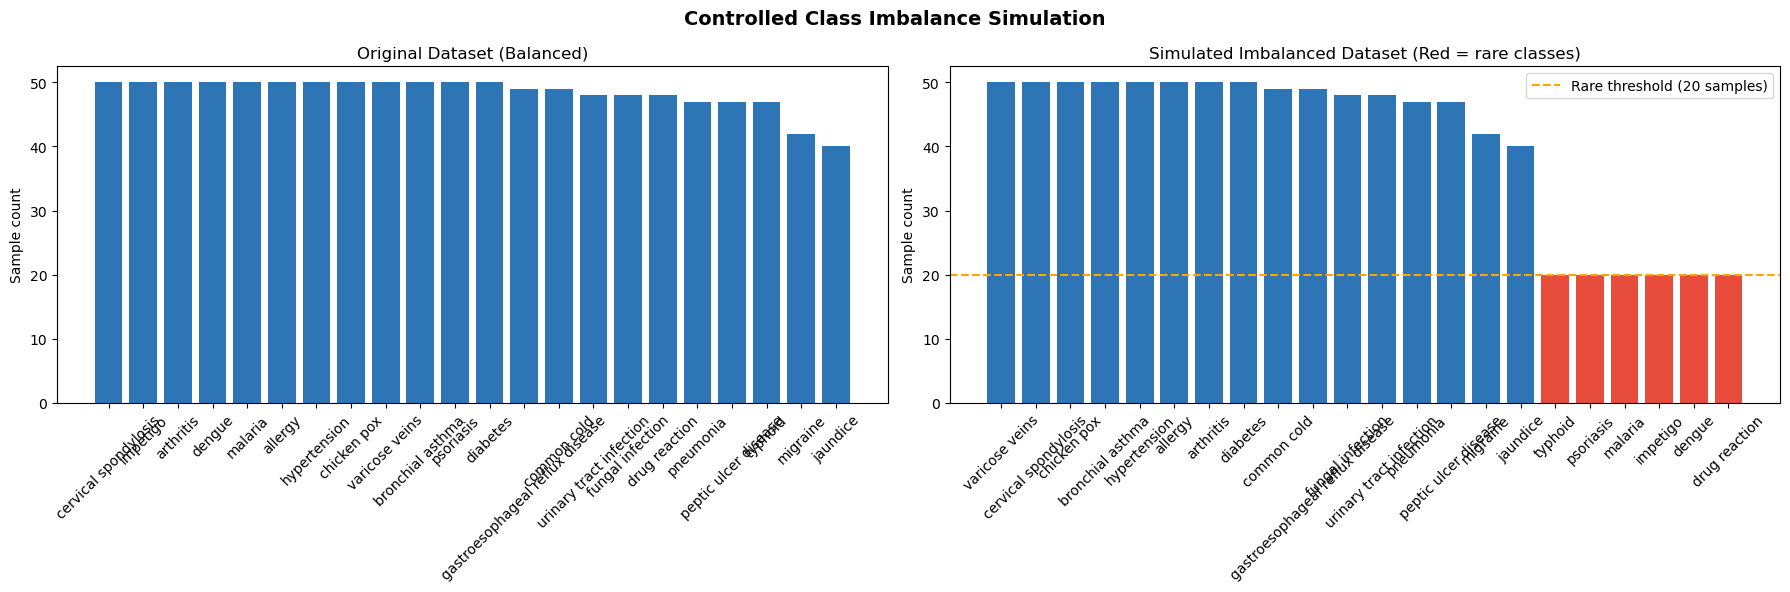

Chart saved — use this figure in the report Methodology section.


In [24]:
# ── Step 4: Visualise the imbalance ──────────────────────────────────────────
import matplotlib.pyplot as plt
from pathlib import Path
FIGURES_DIR = Path('../reports/figures')

counts_imb = df_imbalanced['disease'].value_counts()
colours = ['#E74C3C' if d in RARE_DISEASES else '#2E75B6'
           for d in counts_imb.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Original (balanced)
orig_counts = df['disease'].value_counts()
axes[0].bar(orig_counts.index, orig_counts.values, color='#2E75B6')
axes[0].set_title('Original Dataset (Balanced)')
axes[0].set_ylabel('Sample count')
axes[0].tick_params(axis='x', rotation=45)

# Imbalanced
axes[1].bar(counts_imb.index, counts_imb.values, color=colours)
axes[1].axhline(y=RARE_N_SAMPLES, color='orange', linestyle='--',
                label=f'Rare threshold ({RARE_N_SAMPLES} samples)')
axes[1].set_title('Simulated Imbalanced Dataset (Red = rare classes)')
axes[1].set_ylabel('Sample count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.suptitle('Controlled Class Imbalance Simulation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_imbalance_simulation.png', dpi=150)
plt.show()
print('Chart saved — use this figure in the report Methodology section.')

In [25]:
# ── Step 5: Save both datasets ────────────────────────────────────────────────
# We keep BOTH versions:
#   balanced     → used as the Phase 1 evaluation test set (ground truth)
#   imbalanced   → used as the Phase 1 & 2 training set (the problem to solve)
from pathlib import Path
processed_dir = Path('../data/processed')

# Re-split using the imbalanced version as source
from src.training.trainer import split_data, build_label_maps

train_df, val_df, test_df = split_data(df_imbalanced)
label2id, id2label, le   = build_label_maps(df_imbalanced)

train_df.to_csv(processed_dir / 'train_imbalanced.csv', index=False)
val_df.to_csv(processed_dir   / 'val_imbalanced.csv',   index=False)
test_df.to_csv(processed_dir  / 'test_imbalanced.csv',  index=False)

# Also keep the original balanced split for fair evaluation
train_bal, val_bal, test_bal = split_data(df)
test_bal.to_csv(processed_dir / 'test_balanced.csv', index=False)

# Save rare class list for use in Phase 2
import json
(processed_dir / 'rare_classes.json').write_text(
    json.dumps({'rare_diseases': RARE_DISEASES, 'rare_n_samples': RARE_N_SAMPLES})
)

print('Saved:')
print('  data/processed/train_imbalanced.csv  ← Phase 1 & 2 training input')
print('  data/processed/val_imbalanced.csv    ← Phase 1 & 2 validation')
print('  data/processed/test_imbalanced.csv   ← held-out test set')
print('  data/processed/test_balanced.csv     ← original balanced test (evaluation reference)')
print('  data/processed/rare_classes.json     ← rare class list for Phase 2 VAE')

2026-06-13 22:21:12 | INFO     | src.training.trainer | Split — Train: 712 | Val: 89 | Test: 89
2026-06-13 22:21:12 | INFO     | src.training.trainer | Label map built: 22 classes.
2026-06-13 22:21:12 | INFO     | src.training.trainer | Split — Train: 852 | Val: 106 | Test: 107
Saved:
  data/processed/train_imbalanced.csv  ← Phase 1 & 2 training input
  data/processed/val_imbalanced.csv    ← Phase 1 & 2 validation
  data/processed/test_imbalanced.csv   ← held-out test set
  data/processed/test_balanced.csv     ← original balanced test (evaluation reference)
  data/processed/rare_classes.json     ← rare class list for Phase 2 VAE


## Phase 0 Complete ✅

**What we have:**
- Original balanced dataset (EDA reference)
- Controlled imbalanced dataset (5-7 rare classes at 20 samples each)
- Train/val/test splits saved to `data/processed/`
- Class distribution charts saved to `reports/figures/`

**Experiment design for Phase 1 & 2:**

| Model | Training data | Purpose |
|-------|--------------|--------|
| Baseline BERT | `train_imbalanced.csv` | Shows the problem — poor F1 on rare classes |
| Augmented BERT | `train_imbalanced.csv` + VAE synthetic | Shows the fix — improved rare class F1 |

**Evaluation is always on `test_imbalanced.csv`** (same held-out set for both models, fair comparison).

> Copy the class imbalance simulation chart and this experiment table into your report's Methodology section.

In [ ]:
counts = df['disease'].value_counts()
rare_threshold = get('data.rare_class_threshold', 100)

print(f'Total classes:  {len(counts)}')
print(f'Rare classes:   {(counts < rare_threshold).sum()}  (< {rare_threshold} samples)')

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
colours = ['#E74C3C' if c < rare_threshold else '#2E75B6' for c in counts.values]
ax.bar(counts.index, counts.values, color=colours)
ax.axhline(y=rare_threshold, color='orange', linestyle='--',
           label=f'Rare threshold ({rare_threshold})')
ax.set_xlabel('Disease')
ax.set_ylabel('Sample count')
ax.set_title('Class Distribution — Red = rare classes targeted for VAE augmentation')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 3. Preprocessing Verification

In [ ]:
# Spot-check on 10 samples
samples = df['symptoms'].sample(10, random_state=42).tolist()
for orig in samples:
    proc = preprocess(orig)
    print(f'ORIGINAL:  {orig[:100]}')
    print(f'PROCESSED: {proc[:100]}')
    print()

In [ ]:
# Batch preprocess full dataset
print('Batch preprocessing...')
df['symptoms_clean'] = preprocess_batch(df['symptoms'].tolist())
print('Done.')
df[['symptoms','symptoms_clean','disease']].head()

## 4. Train / Val / Test Split

In [ ]:
train_df, val_df, test_df = split_data(df)
label2id, id2label, le   = build_label_maps(df)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Classes: {len(label2id)}')

processed_dir = Path('../data/processed')
train_df.to_csv(processed_dir / 'train.csv', index=False)
val_df.to_csv(processed_dir   / 'val.csv',   index=False)
test_df.to_csv(processed_dir  / 'test.csv',  index=False)
print('Splits saved.')

## 5. Phase 0 Summary

Fill in after running:

| Metric | Value |
|--------|-------|
| Total samples | — |
| Disease classes | — |
| Rare classes | — |
| Train / Val / Test | — / — / — |

> Copy this table into the report Methodology section.